# Preliminary Analysis — SEC Litigation Releases Dataset

A comprehensive look at the structure, coverage, and distributions of the dataset before any modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('sec_litigation_releases_20260403_234416.csv', encoding='utf-8', on_bad_lines='skip')
print(f'Dataset shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')

Dataset shape: 10,914 rows  ×  39 columns


## 1. Column Overview — What Do We Have?

In [2]:
col_info = []
for col in df.columns:
    non_null = df[col].dropna().astype(str).str.strip().replace('', np.nan).dropna().shape[0]
    pct = non_null / len(df) * 100
    col_info.append({
        'Column': col,
        'Non-Empty': f'{non_null:,}',
        'Coverage (%)': round(pct, 1),
    })

info_df = pd.DataFrame(col_info)
info_df = info_df.sort_values('Coverage (%)', ascending=False).reset_index(drop=True)
info_df['Coverage (%)'] = info_df['Coverage (%)'].apply(lambda x: f'{x}%')
info_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Column,Non-Empty,Coverage (%)
case_title,"10,914",100.0%
date,"10,914",100.0%
petitioner,"10,914",100.0%
respondent,"10,914",100.0%
source_url,"10,914",100.0%
citation,"10,914",100.0%
summary,"10,914",100.0%
legal_topic,"10,752",98.5%
related_releases,"10,446",95.7%
judgment_type,"10,322",94.6%


## 2. Data Completeness — Bar Chart

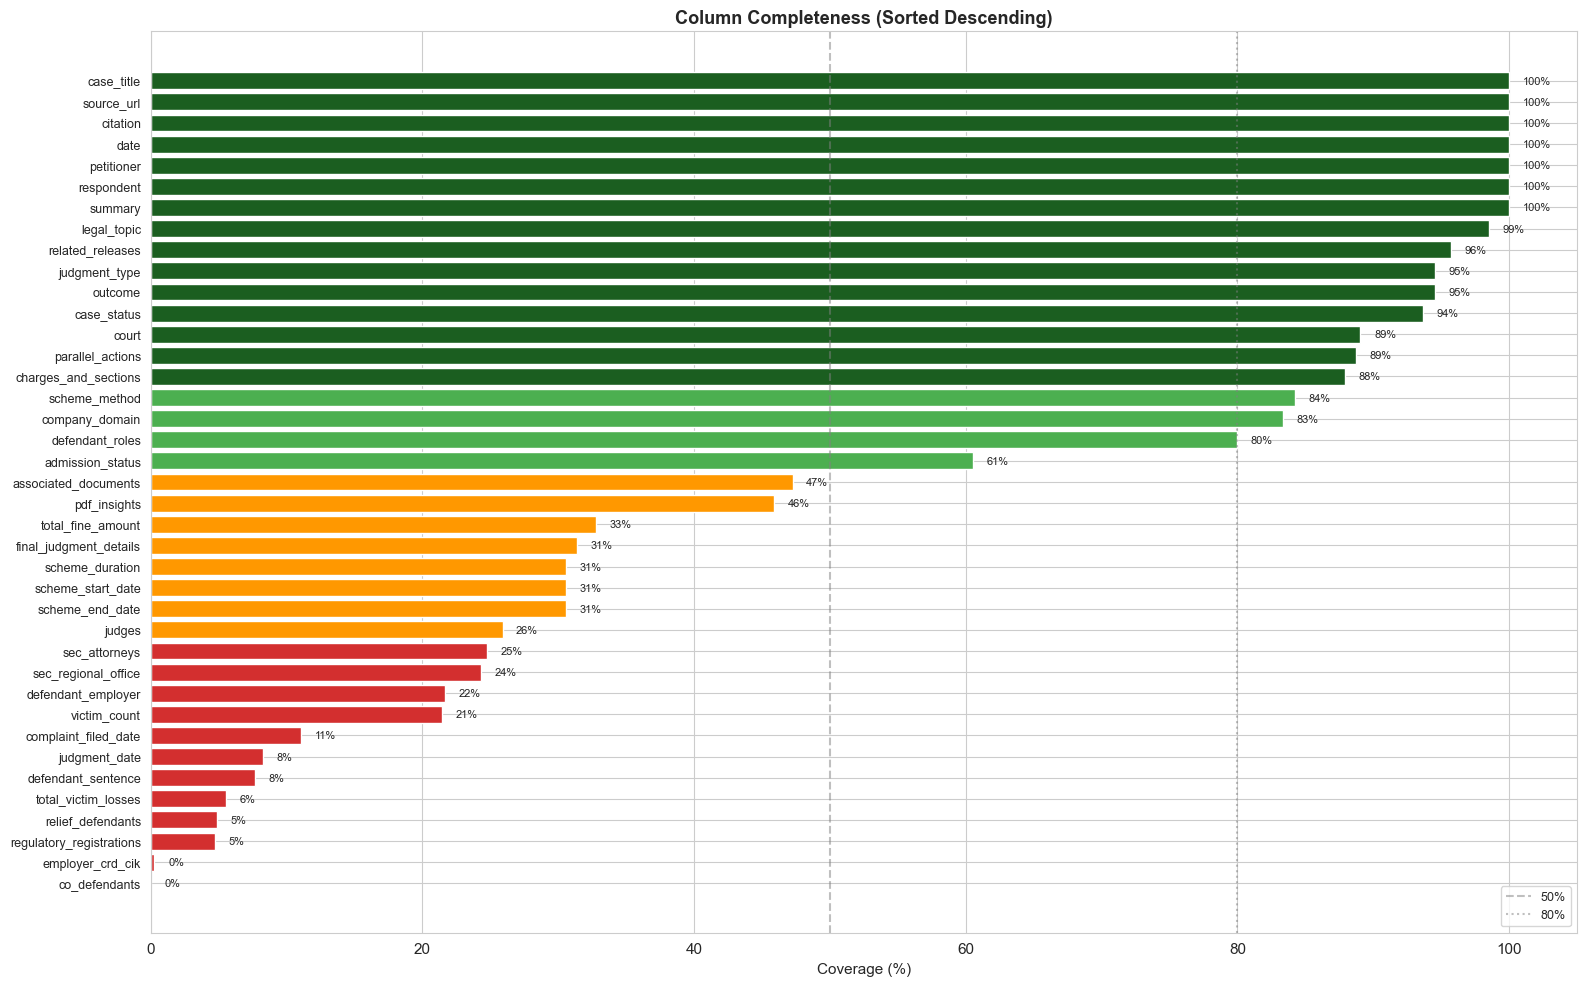

In [3]:
coverage_data = {}
for col in df.columns:
    non_null = df[col].dropna().astype(str).str.strip().replace('', np.nan).dropna().shape[0]
    coverage_data[col] = non_null / len(df) * 100

cov_series = pd.Series(coverage_data).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(16, 10))
colors = ['#d32f2f' if v < 25 else '#ff9800' if v < 50 else '#4caf50' if v < 85 else '#1b5e20' for v in cov_series.values]
ax.barh(range(len(cov_series)), cov_series.values, color=colors)
ax.set_yticks(range(len(cov_series)))
ax.set_yticklabels(cov_series.index, fontsize=9)
ax.set_xlabel('Coverage (%)')
ax.set_title('Column Completeness (Sorted Descending)', fontweight='bold', fontsize=13)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
ax.axvline(80, color='gray', linestyle=':', alpha=0.5, label='80%')
ax.legend(fontsize=9)

for i, v in enumerate(cov_series.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('column_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Temporal Coverage — Cases Over Time

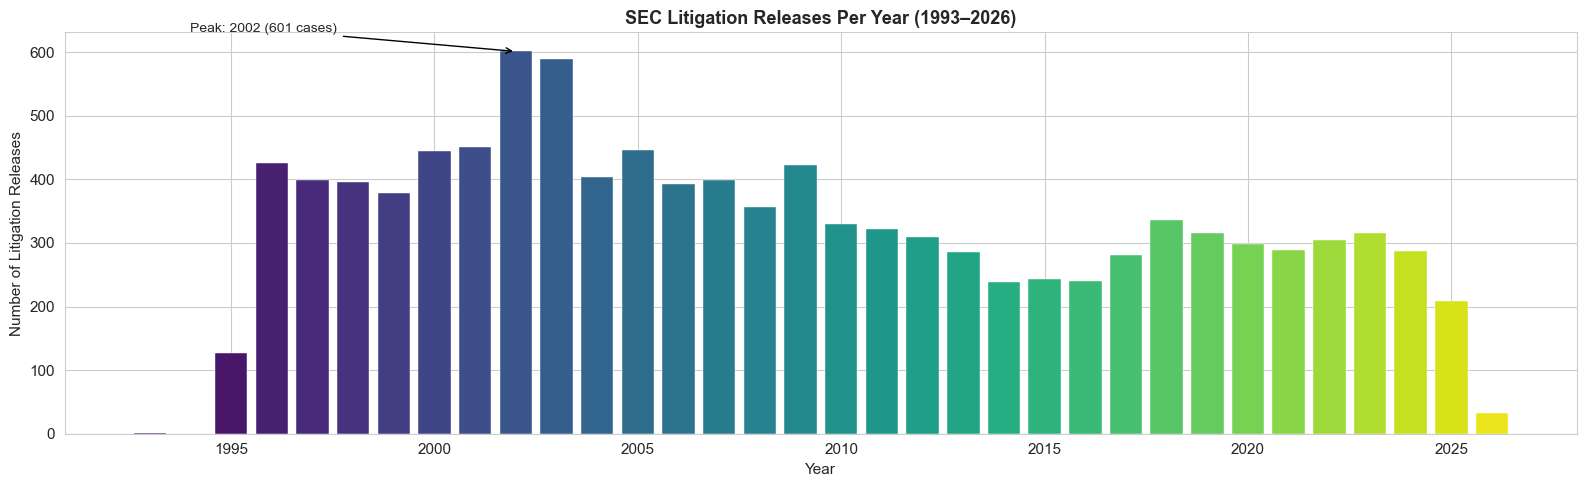

Date range: 1993-03-29 to 2026-04-03
Total span: 33.0 years


In [4]:
df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['parsed_date'].dt.year

yearly = df['year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(yearly.index, yearly.values, color=sns.color_palette('viridis', len(yearly)), edgecolor='white', linewidth=0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Litigation Releases')
ax.set_title('SEC Litigation Releases Per Year (1993–2026)', fontweight='bold', fontsize=13)

peak_year = yearly.idxmax()
ax.annotate(f'Peak: {peak_year} ({yearly.max()} cases)', xy=(peak_year, yearly.max()),
            xytext=(peak_year - 8, yearly.max() + 30), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('cases_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Date range: {df["parsed_date"].min().date()} to {df["parsed_date"].max().date()}')
print(f'Total span: {(df["parsed_date"].max() - df["parsed_date"].min()).days / 365.25:.1f} years')

## 4. Where Are These Cases Filed? — Court Distribution

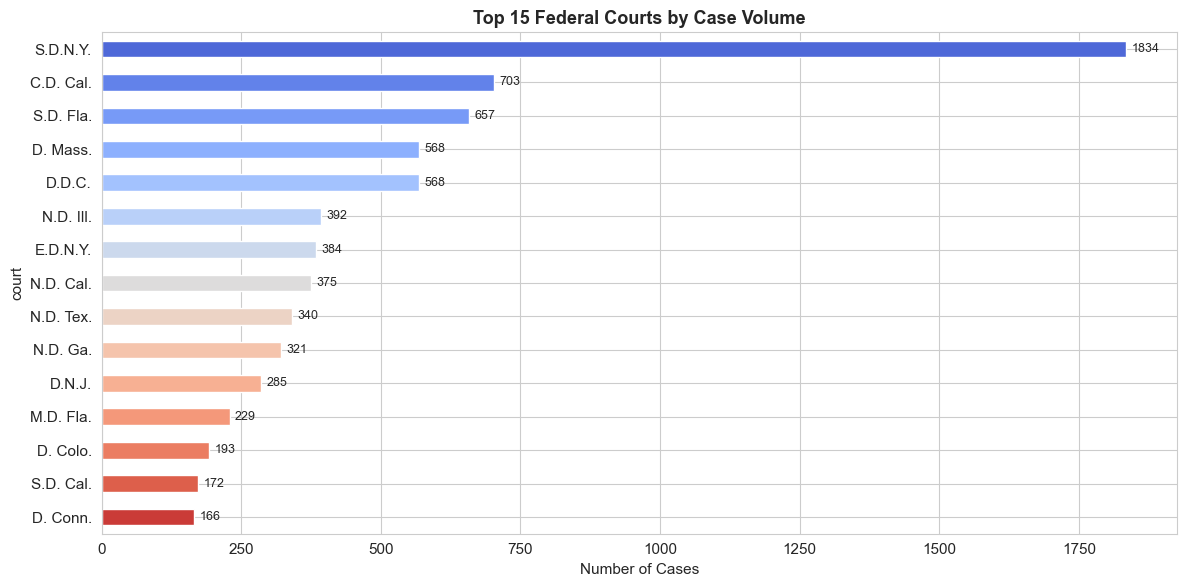

S.D.N.Y. handles 18.9% of all SEC cases — by far the dominant venue.


In [5]:
courts = df['court'].dropna().astype(str).str.strip()
courts = courts[courts != '']
top_courts = courts.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_courts.plot.barh(ax=ax, color=sns.color_palette('coolwarm', len(top_courts)))
ax.invert_yaxis()
ax.set_xlabel('Number of Cases')
ax.set_title('Top 15 Federal Courts by Case Volume', fontweight='bold', fontsize=13)

for i, (v, count) in enumerate(top_courts.items()):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('court_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'S.D.N.Y. handles {top_courts.iloc[0] / len(courts) * 100:.1f}% of all SEC cases — by far the dominant venue.')

## 4b. Courts With the Most Case Outcomes

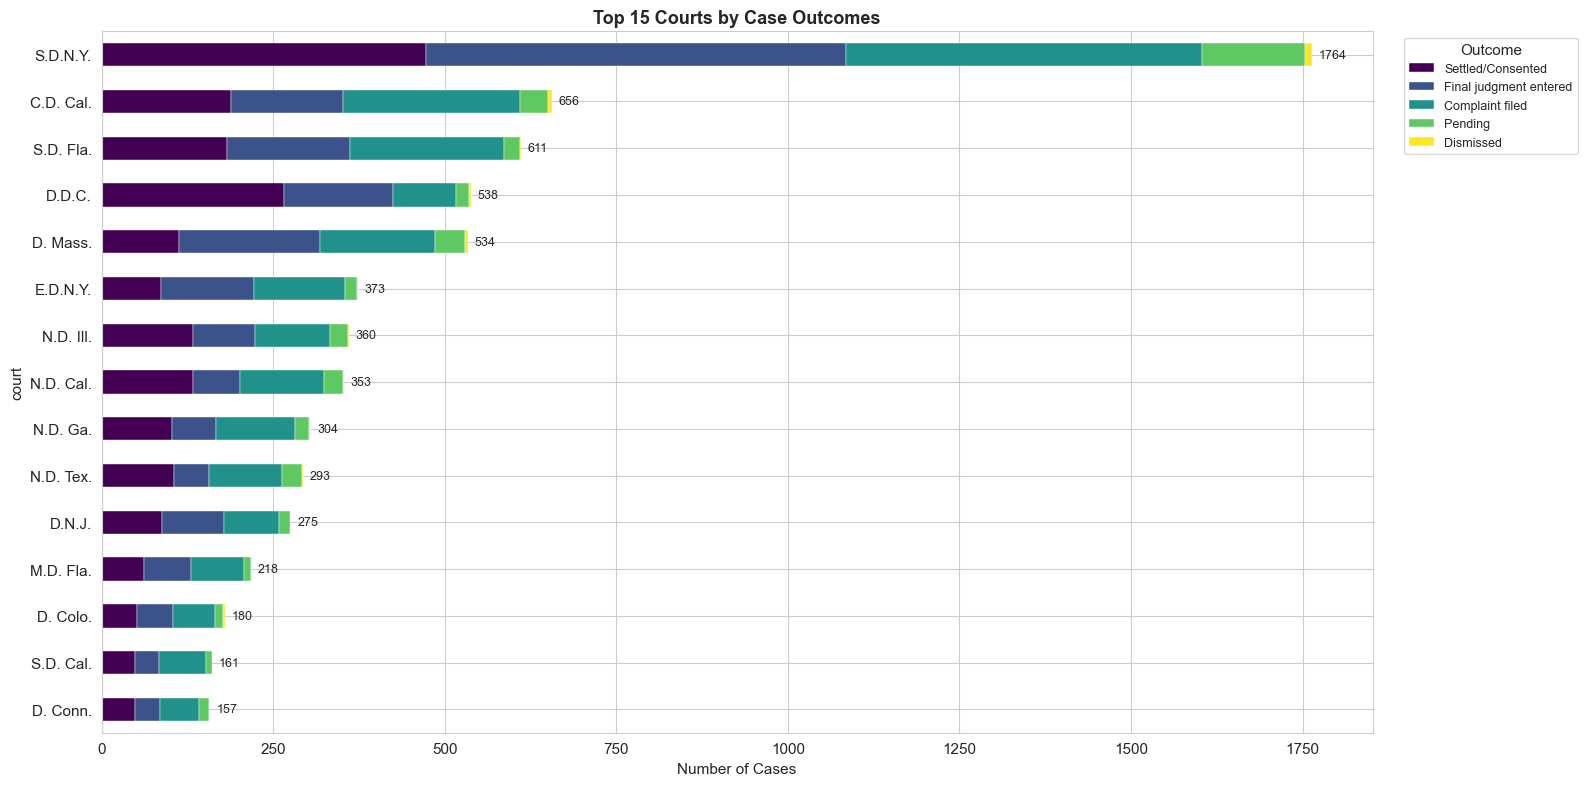


Court outcome tendencies (top 15):
Court                  Total   Settled%   FinalJ%   Complnt%               Tends Toward
-------------------------------------------------------------------------------------
S.D.N.Y.                1764      26.8%     34.7%      29.4%     Final judgment entered (34.7%)
C.D. Cal.                656      28.8%     24.7%      39.5%            Complaint filed (39.5%)
S.D. Fla.                611      30.0%     29.3%      36.8%            Complaint filed (36.8%)
D.D.C.                   538      49.3%     29.6%      17.1%          Settled/Consented (49.3%)
D. Mass.                 534      21.0%     38.6%      31.5%     Final judgment entered (38.6%)
E.D.N.Y.                 373      23.1%     36.5%      35.7%     Final judgment entered (36.5%)
N.D. Ill.                360      36.9%     25.0%      30.6%          Settled/Consented (36.9%)
N.D. Cal.                353      37.7%     19.5%      34.6%          Settled/Consented (37.7%)
N.D. Ga.              

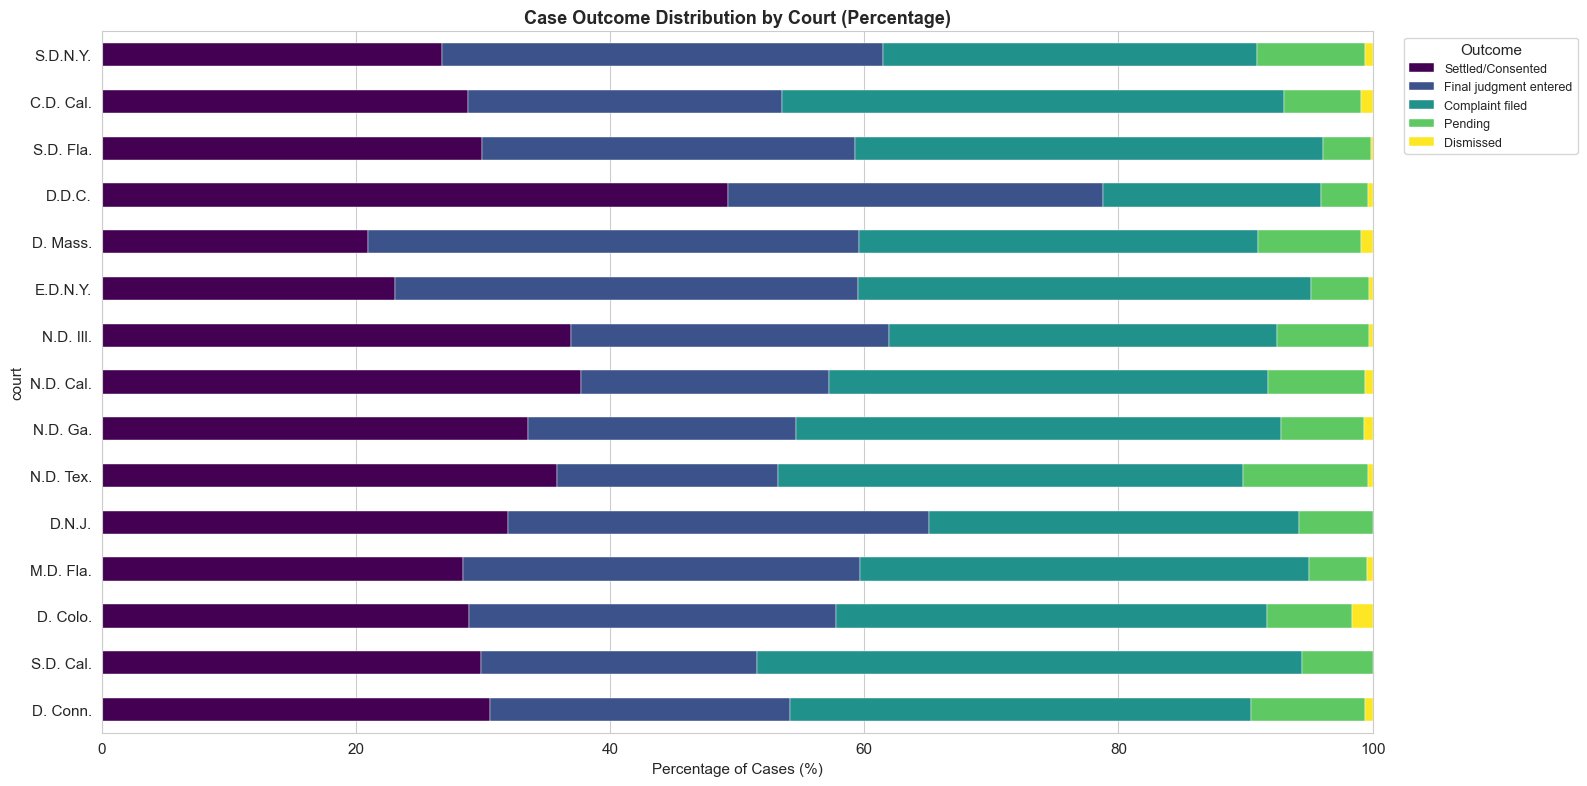

In [6]:
has_outcome = df[df['case_status'].notna() & (df['case_status'].astype(str).str.strip() != '')]
has_outcome = has_outcome[has_outcome['court'].notna() & (has_outcome['court'].astype(str).str.strip() != '')]

has_outcome['primary_status'] = has_outcome['case_status'].astype(str).str.split(';').str[0].str.strip()

court_outcome = has_outcome.groupby('court')['primary_status'].value_counts().unstack(fill_value=0)

top_statuses = ['Settled/Consented', 'Final judgment entered', 'Complaint filed', 'Pending', 'Dismissed']
top_statuses = [s for s in top_statuses if s in court_outcome.columns]

court_outcome['total_outcomes'] = court_outcome[top_statuses].sum(axis=1)
court_outcome = court_outcome.sort_values('total_outcomes', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(16, 8))
court_outcome[top_statuses].plot.barh(stacked=True, ax=ax, colormap='viridis', edgecolor='white', linewidth=0.3)
ax.invert_yaxis()
ax.set_xlabel('Number of Cases')
ax.set_title('Top 15 Courts by Case Outcomes', fontweight='bold', fontsize=13)
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

for i, total in enumerate(court_outcome['total_outcomes']):
    ax.text(total + 10, i, str(total), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('courts_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

court_tendency = []
for court_name, row in court_outcome.iterrows():
    total = int(row['total_outcomes'])
    best_outcome = ''
    best_pct = 0
    for s in top_statuses:
        pct = row.get(s, 0) / total * 100 if total > 0 else 0
        if pct > best_pct:
            best_pct = pct
            best_outcome = s
    court_tendency.append({
        'Court': court_name,
        'Total': total,
        'Settled': int(row.get('Settled/Consented', 0)),
        'Final Judgment': int(row.get('Final judgment entered', 0)),
        'Complaint Filed': int(row.get('Complaint filed', 0)),
        'Dominant Outcome': best_outcome,
        'Dominant %': round(best_pct, 1),
    })

tend_df = pd.DataFrame(court_tendency)

print('\nCourt outcome tendencies (top 15):')
print(f'{"Court":20s}  {"Total":>6s}  {"Settled%":>9s}  {"FinalJ%":>8s}  {"Complnt%":>9s}  {"Tends Toward":>25s}')
print('-' * 85)
for _, r in tend_df.iterrows():
    total = r['Total']
    s_pct = r['Settled'] / total * 100
    f_pct = r['Final Judgment'] / total * 100
    c_pct = r['Complaint Filed'] / total * 100
    print(f'{r["Court"]:20s}  {total:>6d}  {s_pct:>8.1f}%  {f_pct:>7.1f}%  {c_pct:>8.1f}%  {r["Dominant Outcome"]:>25s} ({r["Dominant %"]}%)')

# Visualize the dominant tendency
fig, ax = plt.subplots(figsize=(16, 8))
tend_plot = tend_df.set_index('Court')
for s in top_statuses:
    col = s.replace('/', '_').replace(' ', '_')
    tend_plot[s + ' %'] = tend_plot.apply(
        lambda r: r.get(s.split('/')[0].split(' ')[0], 0) / r['Total'] * 100 if r['Total'] > 0 else 0, axis=1)

pct_cols = {}
for s in top_statuses:
    pct_cols[s] = court_outcome[s].values / court_outcome['total_outcomes'].values * 100

pct_df = pd.DataFrame(pct_cols, index=court_outcome.index)

pct_df.plot.barh(stacked=True, ax=ax, colormap='viridis', edgecolor='white', linewidth=0.3)
ax.invert_yaxis()
ax.set_xlabel('Percentage of Cases (%)')
ax.set_title('Case Outcome Distribution by Court (Percentage)', fontweight='bold', fontsize=13)
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('courts_outcome_tendency.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Legal Topics — What Violations Does the SEC Pursue?

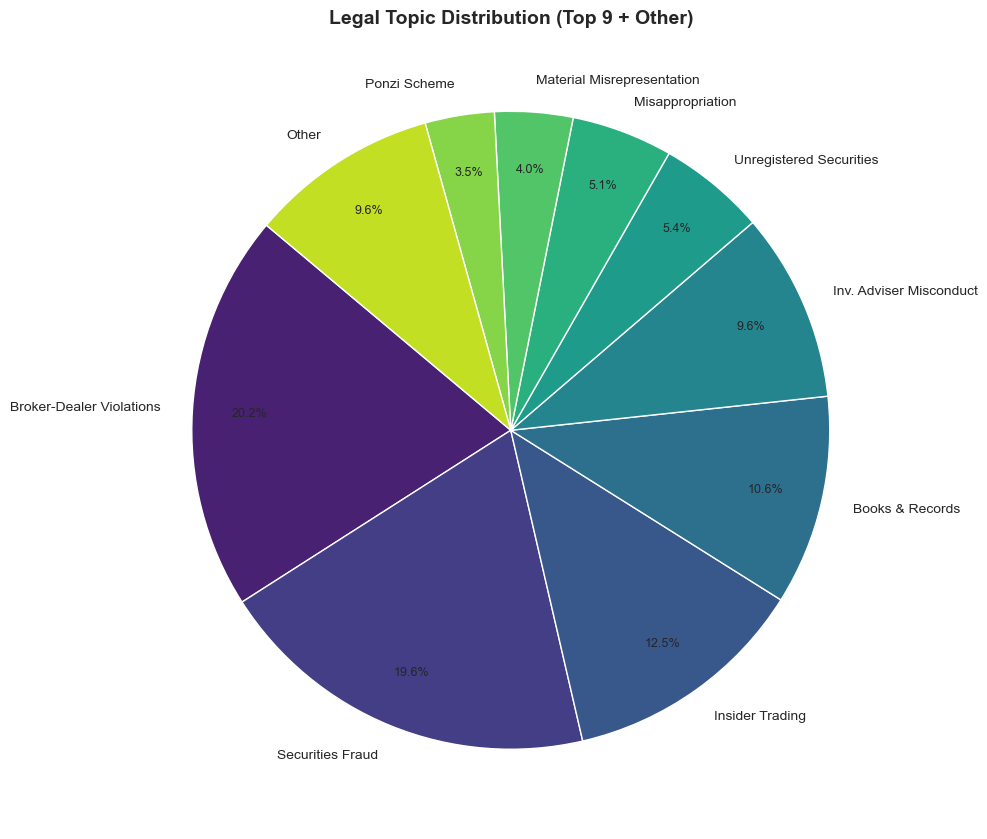

In [7]:
topics_raw = df['legal_topic'].dropna().astype(str).str.strip()
topics_raw = topics_raw[topics_raw != '']

primary_topic = topics_raw.str.split(';').str[0].str.strip()
all_counts = primary_topic.value_counts()
top9 = all_counts.head(9)
other_count = all_counts.iloc[9:].sum()
pie_data = pd.concat([top9, pd.Series({'Other': other_count})])

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
    startangle=140, colors=sns.color_palette('viridis', len(pie_data)),
    textprops={'fontsize': 10}, pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Legal Topic Distribution (Top 9 + Other)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('legal_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Case Outcomes — How Do Cases Resolve?

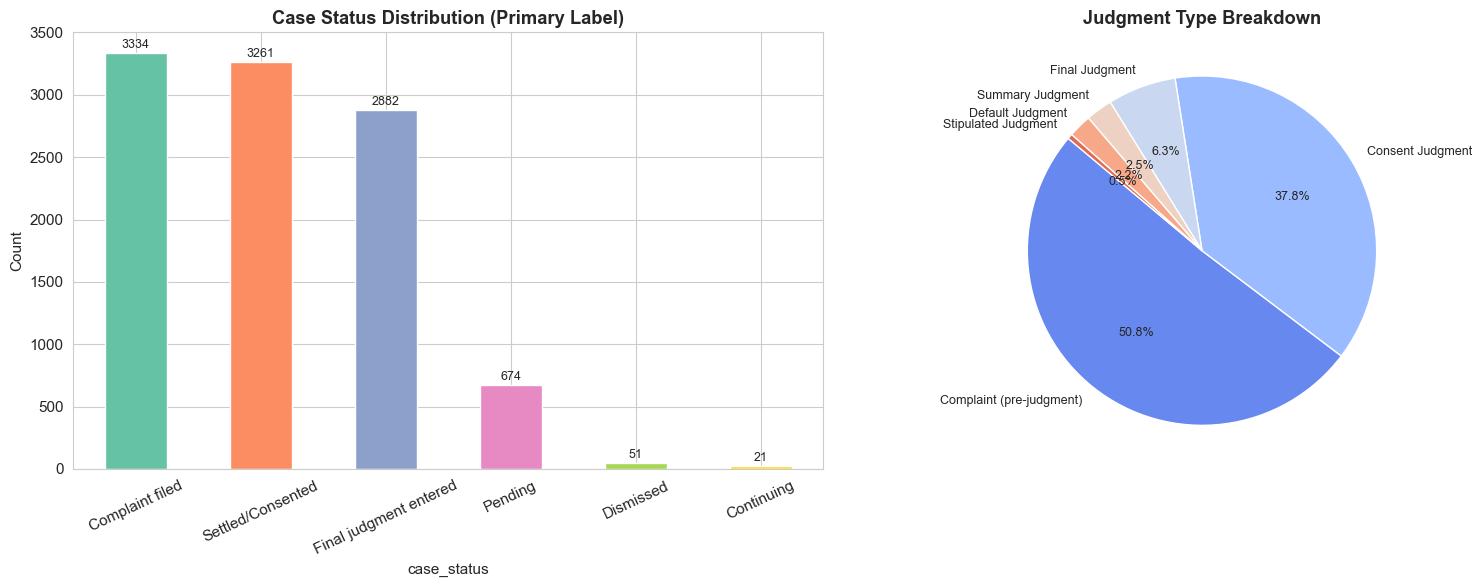

In [8]:
status_raw = df['case_status'].dropna().astype(str).str.strip()
status_raw = status_raw[status_raw != '']
primary_status = status_raw.str.split(';').str[0].str.strip()
status_counts = primary_status.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Set2', len(status_counts))
status_counts.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Case Status Distribution (Primary Label)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, (v, count) in enumerate(status_counts.items()):
    axes[0].text(i, count + 40, str(count), ha='center', fontsize=9)

# Judgment type breakdown
jt = df['judgment_type'].dropna().astype(str).str.strip()
jt = jt[jt != '']
primary_jt = jt.str.split(';').str[0].str.strip()
jt_counts = primary_jt.value_counts().head(6)
jt_counts.plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=140,
                   colors=sns.color_palette('coolwarm', len(jt_counts)),
                   textprops={'fontsize': 9})
axes[1].set_ylabel('')
axes[1].set_title('Judgment Type Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('case_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Industry Domains — Who Does the SEC Go After?

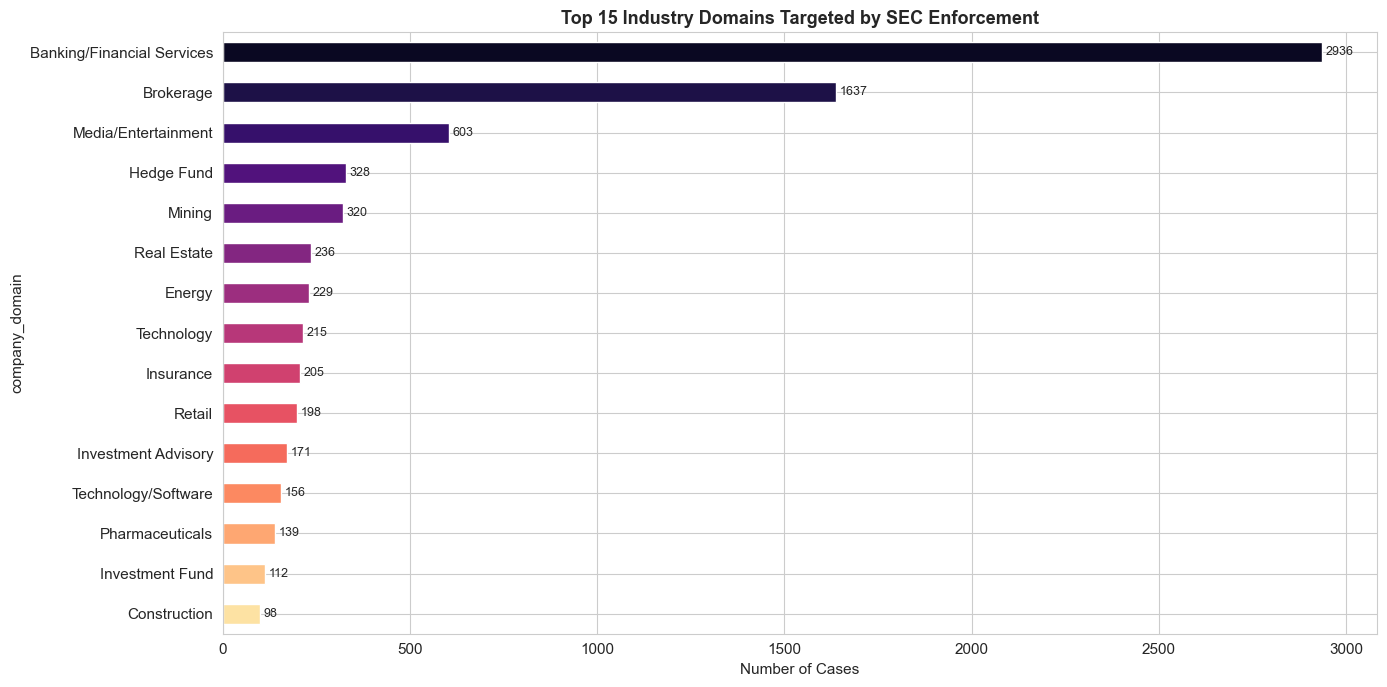

Banking/Financial Services alone accounts for 32.3% of all cases with a domain label.


In [9]:
domain_raw = df['company_domain'].dropna().astype(str).str.strip()
domain_raw = domain_raw[domain_raw != '']
primary_domain = domain_raw.str.split(';').str[0].str.strip()
domain_counts = primary_domain.value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
domain_counts.plot.barh(ax=ax, color=sns.color_palette('magma', len(domain_counts)))
ax.invert_yaxis()
ax.set_xlabel('Number of Cases')
ax.set_title('Top 15 Industry Domains Targeted by SEC Enforcement', fontweight='bold', fontsize=13)

for i, (v, count) in enumerate(domain_counts.items()):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('industry_domains.png', dpi=150, bbox_inches='tight')
plt.show()

banking_pct = domain_counts.iloc[0] / primary_domain.shape[0] * 100
print(f'Banking/Financial Services alone accounts for {banking_pct:.1f}% of all cases with a domain label.')

## 8. Admission Status — Do Defendants Admit or Deny?

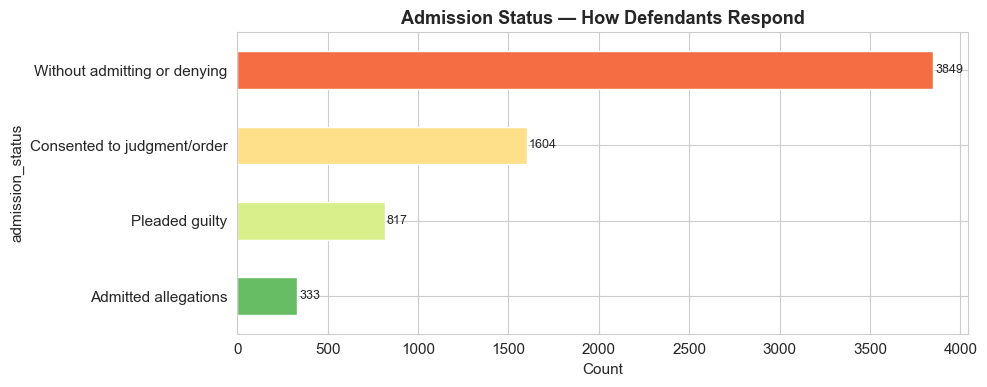

In [10]:
admission = df['admission_status'].dropna().astype(str).str.strip()
admission = admission[admission != '']
adm_counts = admission.value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
adm_counts.plot.barh(ax=ax, color=sns.color_palette('RdYlGn', len(adm_counts)))
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title('Admission Status — How Defendants Respond', fontweight='bold', fontsize=13)
for i, (v, count) in enumerate(adm_counts.items()):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('admission_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Text — Length Distribution

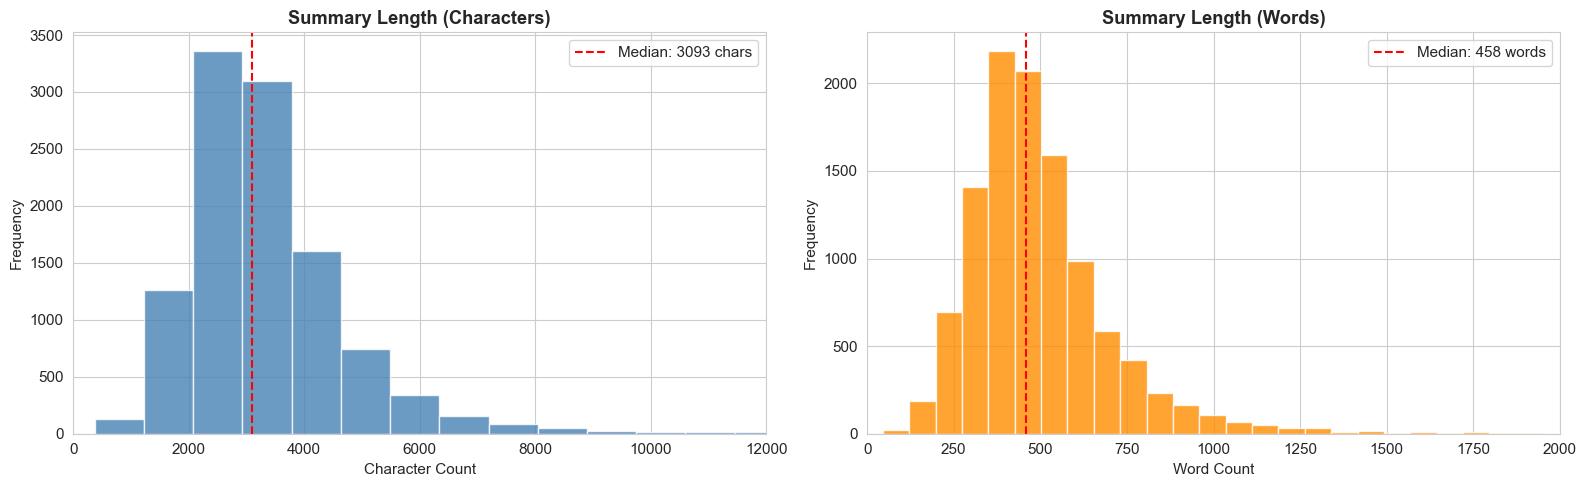

Character count — Mean: 3367, Median: 3093, Max: 68,570
Word count      — Mean: 500, Median: 458, Max: 6,137


In [11]:
df['summary_len'] = df['summary'].str.len()
df['summary_words'] = df['summary'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['summary_len'].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['summary_len'].median(), color='red', linestyle='--', label=f'Median: {df["summary_len"].median():.0f} chars')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Summary Length (Characters)', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 12000)

axes[1].hist(df['summary_words'].dropna(), bins=80, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(df['summary_words'].median(), color='red', linestyle='--', label=f'Median: {df["summary_words"].median():.0f} words')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Summary Length (Words)', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('summary_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Character count — Mean: {df["summary_len"].mean():.0f}, Median: {df["summary_len"].median():.0f}, Max: {df["summary_len"].max():,}')
print(f'Word count      — Mean: {df["summary_words"].mean():.0f}, Median: {df["summary_words"].median():.0f}, Max: {df["summary_words"].max():,}')

## 10. Charges & Statutes — What Laws Are Most Cited?

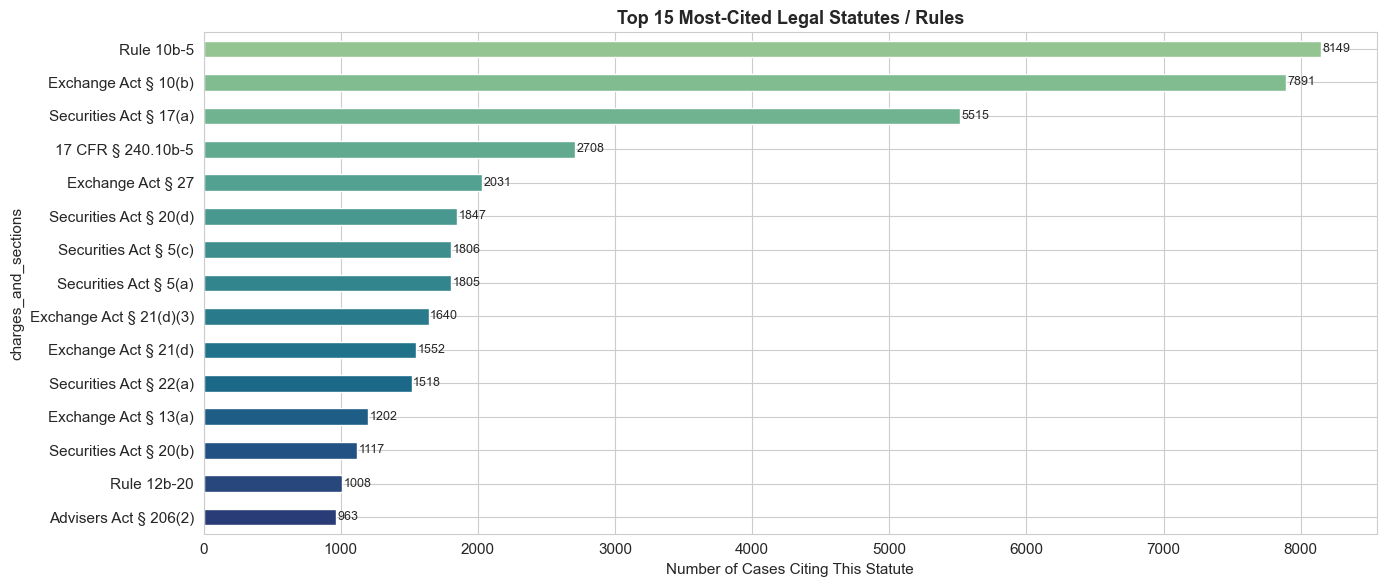

In [12]:
charges_raw = df['charges_and_sections'].dropna().astype(str).str.strip()
charges_raw = charges_raw[charges_raw != '']
all_charges = charges_raw.str.split(';').explode().str.strip()
all_charges = all_charges[all_charges != '']
charge_counts = all_charges.value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 6))
charge_counts.plot.barh(ax=ax, color=sns.color_palette('crest', len(charge_counts)))
ax.invert_yaxis()
ax.set_xlabel('Number of Cases Citing This Statute')
ax.set_title('Top 15 Most-Cited Legal Statutes / Rules', fontweight='bold', fontsize=13)

for i, (v, count) in enumerate(charge_counts.items()):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charges_statutes.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Parallel Criminal Actions

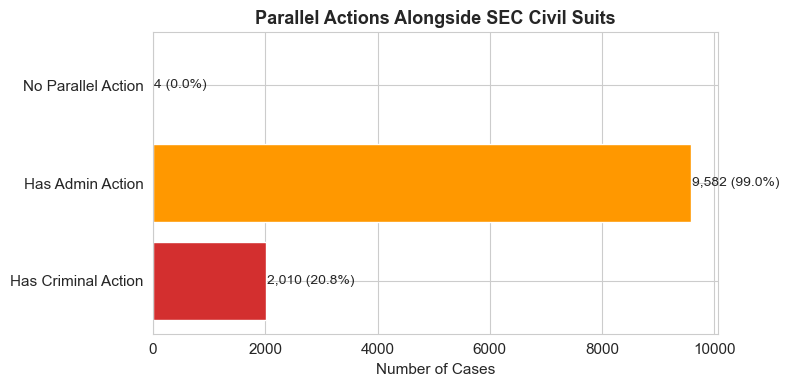

In [13]:
parallel = df['parallel_actions'].dropna().astype(str).str.strip()
parallel = parallel[parallel != '']

has_criminal = parallel.str.contains('Criminal', case=False, na=False).sum()
has_admin = parallel.str.contains('Admin', case=False, na=False).sum()
has_none = parallel.str.contains('None|no parallel', case=False, na=False).sum()

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Has Criminal Action', 'Has Admin Action', 'No Parallel Action']
values = [has_criminal, has_admin, has_none]
ax.barh(labels, values, color=['#d32f2f', '#ff9800', '#4caf50'])
ax.set_xlabel('Number of Cases')
ax.set_title('Parallel Actions Alongside SEC Civil Suits', fontweight='bold', fontsize=13)
for i, v in enumerate(values):
    ax.text(v + 20, i, f'{v:,} ({v/len(parallel)*100:.1f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('parallel_actions.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cross-Tabulation — Legal Topic vs. Case Status

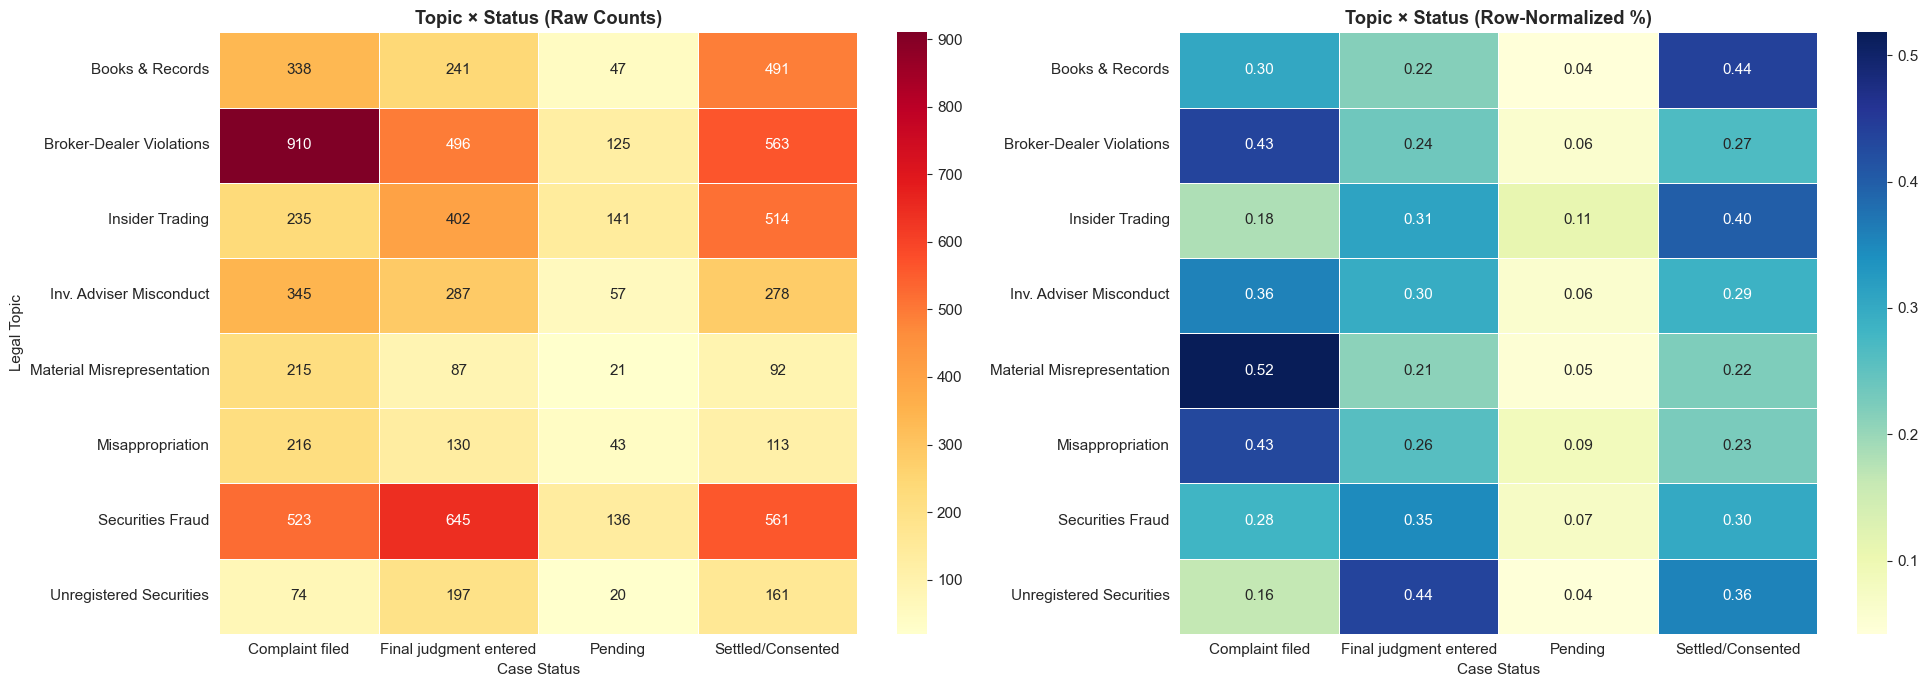

In [14]:
df['primary_topic'] = df['legal_topic'].astype(str).str.split(';').str[0].str.strip()
df['primary_status'] = df['case_status'].astype(str).str.split(';').str[0].str.strip()
df['primary_domain'] = df['company_domain'].astype(str).str.split(';').str[0].str.strip()

# Keep top categories only for readable heatmap
top_topics = df['primary_topic'].value_counts().head(8).index
top_statuses = ['Complaint filed', 'Settled/Consented', 'Final judgment entered', 'Pending']

cross = pd.crosstab(
    df[df['primary_topic'].isin(top_topics)]['primary_topic'],
    df[df['primary_status'].isin(top_statuses)]['primary_status']
)
# Normalize by row
cross_norm = cross.div(cross.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], linewidths=0.5)
axes[0].set_title('Topic × Status (Raw Counts)', fontweight='bold')
axes[0].set_ylabel('Legal Topic')
axes[0].set_xlabel('Case Status')

sns.heatmap(cross_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1], linewidths=0.5)
axes[1].set_title('Topic × Status (Row-Normalized %)', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Case Status')

plt.tight_layout()
plt.savefig('topic_vs_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Legal Topics Over Time — What's Trending?

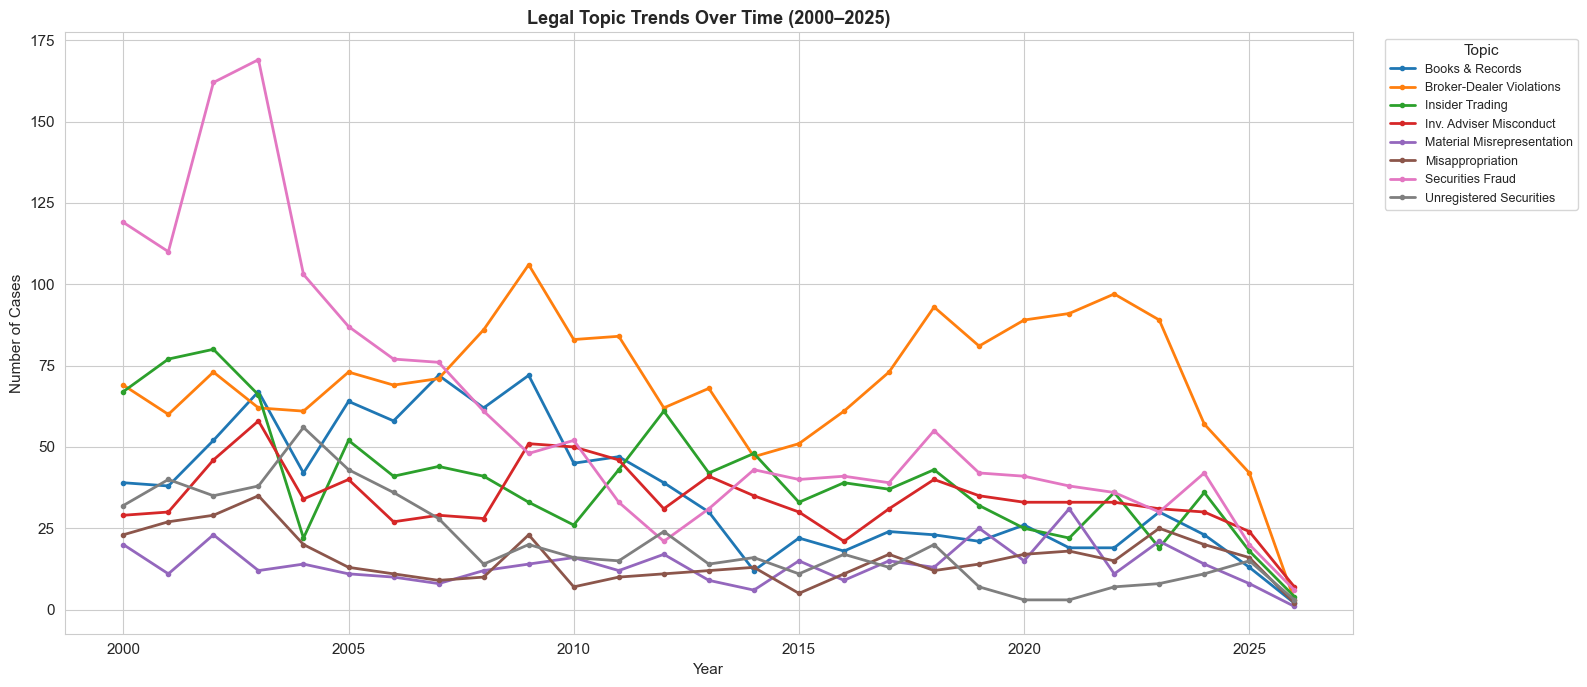

In [15]:
topic_trends = df[df['primary_topic'].isin(top_topics) & df['year'].notna()].copy()
topic_trends['year'] = topic_trends['year'].astype(int)
topic_trends = topic_trends[topic_trends['year'] >= 2000]

trend_pivot = topic_trends.groupby(['year', 'primary_topic']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
trend_pivot.plot(ax=ax, linewidth=2, marker='o', markersize=3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Cases')
ax.set_title('Legal Topic Trends Over Time (2000–2025)', fontweight='bold', fontsize=13)
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('topic_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Quick Data Quality Summary

In [ ]:
print('=' * 65)
print('  DATA QUALITY SUMMARY')
print('=' * 65)
print(f'  Total records:              {len(df):>8,}')
print(f'  Date range:                 {df["parsed_date"].min().date()} to {df["parsed_date"].max().date()}')
print(f'  Unique courts:              {df["court"].nunique():>8,}')
print(f'  Unique legal topics:        {df["primary_topic"].nunique():>8,}')
print(f'  Unique domains:             {df["primary_domain"].nunique():>8,}')
print()
print('  --- Column Tiers by Coverage ---')
full = [c for c in df.columns if df[c].notna().mean() > 0.9]
good = [c for c in df.columns if 0.5 <= df[c].notna().mean() <= 0.9]
sparse = [c for c in df.columns if df[c].notna().mean() < 0.5]
print(f'  >90% complete ({len(full)} cols):   {full}')
print(f'  50–90% ({len(good)} cols):          {good}')
print(f'  <50% ({len(sparse)} cols):          {sparse}')
print()
print('  --- Key Insight ---')
print('  Core fields (case_title, date, summary, legal_topic, case_status)')
print('  are nearly 100% populated. Financial details (fines, losses,')
print('  victim counts) are sparse (5–33%) — these are harder to extract')
print('  from unstructured release text and vary in format.')

  DATA QUALITY SUMMARY
  Total records:                10,914
  Date range:                 1993-03-29 to 2026-04-03
  Unique courts:                   647
  Unique legal topics:              23
  Unique domains:                  689

  --- Column Tiers by Coverage ---
  >90% complete (19 cols):   ['case_title', 'citation', 'date', 'petitioner', 'respondent', 'judgment_type', 'summary', 'outcome', 'legal_topic', 'related_releases', 'case_status', 'source_url', 'parsed_date', 'year', 'summary_len', 'summary_words', 'primary_topic', 'primary_status', 'primary_domain']
  50–90% (7 cols):          ['court', 'defendant_roles', 'charges_and_sections', 'company_domain', 'scheme_method', 'admission_status', 'parallel_actions']
  <50% (20 cols):          ['defendant_employer', 'employer_crd_cik', 'co_defendants', 'relief_defendants', 'sec_attorneys', 'sec_regional_office', 'judges', 'total_fine_amount', 'total_victim_losses', 'scheme_duration', 'victim_count', 'scheme_start_date', 'scheme_end_d